<div class="alert alert-block alert-success">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>
    
Olá, Iago

Meu nome é Ramon. 



Obrigado por enviar seu projeto. 
    
Parabéns, você fez um excelente plano de trabalho. Está bastante maduro. Não tenho sugestão de melhorias (lembre-se de calibrar hiperparâmetros geralmente usamos RandomizedSearchCV). Apenas deixei um comentário sobre o scatter plot. Com certeza será um projeto de muita qualidade. Conte conosco. Parabéns pela dedicação


</div>


# Projeto Final — Etapa 1: Plano de Trabalho

## Previsão da temperatura do metal para otimização energética na Steelproof

Neste projeto, o objetivo é elaborar um plano de trabalho para desenvolver posteriormente um modelo de machine learning capaz de prever a temperatura do metal durante o processamento do aço.

A proposta está inserida no contexto da siderurgia, em que o controle térmico é um fator crítico para:
- reduzir consumo de energia;
- evitar superaquecimento ou aquecimento insuficiente;
- melhorar a estabilidade do processo;
- apoiar decisões operacionais mais eficientes.

Nesta primeira etapa, será realizado:
1. o entendimento do problema de negócio;
2. a descrição e o diagnóstico inicial dos dados;
3. a formulação de hipóteses de modelagem;
4. a definição de indicadores de desempenho (KPIs);
5. a proposição de um desenho experimental;
6. a construção de um plano de execução para a etapa de modelagem.

## 1. Identificação do problema de negócio

A Steelproof busca reduzir seus custos de produção por meio da otimização do consumo de energia na etapa de processamento do aço. Nesse contexto, a temperatura do metal é uma variável operacional central, pois influencia diretamente o volume de energia necessário para aquecimento, a qualidade metalúrgica do produto final e a eficiência do fluxo produtivo.

Em operações de metalurgia secundária, como o tratamento do aço em panela, o controle térmico é essencial para garantir que o metal alcance a faixa adequada de temperatura antes das etapas seguintes, como refino adicional ou lingotamento contínuo. Uma temperatura abaixo do ideal pode comprometer a processabilidade do aço, enquanto uma temperatura excessiva pode gerar desperdício energético, desgaste dos materiais refratários e aumento dos custos operacionais.

Assim, desenvolver um modelo capaz de prever a temperatura final do metal pode gerar valor ao negócio ao permitir decisões mais precisas sobre aquecimento, adição de materiais e tempo de processo. Isso tende a contribuir para maior eficiência energética, redução de custos e maior estabilidade operacional.

## 2. Descrição dos dados

Os dados do projeto estão distribuídos em múltiplos arquivos, cada um representando uma etapa ou aspecto específico do processamento do aço. Todos os conjuntos possuem a coluna `key`, que identifica o lote processado.

Como diferentes eventos podem ocorrer diversas vezes ao longo do tratamento de um mesmo lote, não se espera necessariamente uma linha única por `key` em todos os arquivos. Por isso, antes de qualquer modelagem, é necessário entender a estrutura de cada dataset, seu volume de observações, a granularidade dos registros e possíveis problemas de qualidade de dados.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
data_arc = pd.read_csv('CSV Archives/data_arc_en.csv')
data_bulk = pd.read_csv('CSV Archives/data_bulk_en.csv')
data_bulk_time = pd.read_csv('CSV Archives/data_bulk_time_en.csv')
data_gas = pd.read_csv('CSV Archives/data_gas_en.csv')
data_temp = pd.read_csv('CSV Archives/data_temp_en.csv')
data_wire = pd.read_csv('CSV Archives/data_wire_en.csv')
data_wire_time = pd.read_csv('CSV Archives/data_wire_time_en.csv')

In [3]:
datasets = {
    'data_arc': data_arc,
    'data_bulk': data_bulk,
    'data_bulk_time': data_bulk_time,
    'data_gas': data_gas,
    'data_temp': data_temp,
    'data_wire': data_wire,
    'data_wire_time': data_wire_time
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

data_arc: (14876, 5)
data_bulk: (3129, 16)
data_bulk_time: (3129, 16)
data_gas: (3239, 2)
data_temp: (15907, 3)
data_wire: (3081, 10)
data_wire_time: (3081, 10)


In [4]:
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.head())


data_arc


,key,Arc heating start,Arc heating end,Active power,Reactive power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.98,0.69
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.81,0.52
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.74,0.50
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.66,1.06
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.69,0.41



data_bulk


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,150.00,154.00
1,2,NaN,NaN,NaN,73.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,149.00,154.00
2,3,NaN,NaN,NaN,34.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.00,NaN,152.00,153.00
3,4,NaN,NaN,NaN,81.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.00,NaN,153.00,154.00
4,5,NaN,NaN,NaN,78.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.00,NaN,151.00,152.00



data_bulk_time


...

,key,Sampling time,Temperature
0,1,2019-05-03 11:16:18,1571.00
1,1,2019-05-03 11:25:53,1604.00
2,1,2019-05-03 11:29:11,1618.00
3,1,2019-05-03 11:30:01,1601.00
4,1,2019-05-03 11:30:39,1613.00



data_wire


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.24,9.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN



data_wire_time


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:11:41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:13:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:48:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:18:15,2019-05-03 13:32:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
summary = []

for name, df in datasets.items():
    summary.append({
        'dataset': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'duplicated_rows': df.duplicated().sum(),
        'unique_keys': df['key'].nunique() if 'key' in df.columns else None
    })

summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,columns,duplicated_rows,unique_keys
0,data_arc,14876,5,0,3214
1,data_bulk,3129,16,0,3129
2,data_bulk_time,3129,16,0,3129
3,data_gas,3239,2,0,3239
4,data_temp,15907,3,0,3216
5,data_wire,3081,10,0,3081
6,data_wire_time,3081,10,0,3081


### 2.1 Estrutura inicial dos conjuntos de dados

A inspeção inicial mostra que os dados estão distribuídos em sete arquivos com volumes e granularidades distintas. O maior conjunto é `data_temp`, com 15.907 registros e 3 colunas, seguido por `data_arc`, com 14.876 registros e 5 colunas. Esses dois arquivos apresentam múltiplas observações por lote, o que é coerente com a natureza iterativa do processo siderúrgico, em que medições de temperatura e operações de aquecimento podem ocorrer diversas vezes para a mesma panela.

Já os arquivos `data_bulk`, `data_bulk_time`, `data_wire` e `data_wire_time` têm quantidade de linhas muito próxima do número de lotes únicos, sugerindo uma estrutura mais consolidada por lote. O arquivo `data_gas`, com 3.239 registros e apenas 2 colunas, também parece representar uma informação agregada por lote.

Além disso, não foram encontrados registros totalmente duplicados em nenhum dos datasets, o que é um sinal positivo de qualidade estrutural inicial. Ainda assim, será necessário avaliar valores ausentes, tipos de dados e coerência temporal antes de definir a base final de modelagem.

In [6]:
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.info())
    print('\nValores ausentes por coluna:')
    print(df.isna().sum())
    print('=' * 100)


data_arc
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                14876 non-null  int64  
 1   Arc heating start  14876 non-null  object 
 2   Arc heating end    14876 non-null  object 
 3   Active power       14876 non-null  float64
 4   Reactive power     14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
None

Valores ausentes por coluna:
key                  0
Arc heating start    0
Arc heating end      0
Active power         0
Reactive power       0
dtype: int64

data_bulk
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3

In [7]:
for name, df in datasets.items():
    print(f'\n{name} — estatísticas descritivas numéricas')
    display(df.describe())


data_arc — estatísticas descritivas numéricas


,key,Active power,Reactive power
count,14876.00,14876.00,14876.00
mean,1615.22,0.67,0.45
std,934.57,0.41,5.88
min,1.00,0.03,-715.50
25%,806.00,0.40,0.29
50%,1617.00,0.56,0.42
75%,2429.00,0.86,0.64
max,3241.00,3.73,2.68



data_bulk — estatísticas descritivas numéricas


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.00,252.00,22.00,1298.00,1014.00,77.00,576.00,25.00,1.00,19.00,176.00,177.00,2450.00,18.00,2806.00,2248.00
mean,1624.38,39.24,253.05,113.88,104.39,107.03,118.93,305.60,49.00,76.32,83.28,76.82,260.47,181.11,170.28,160.51
std,933.34,18.28,21.18,75.48,48.18,81.79,72.06,191.02,NaN,21.72,26.06,59.66,120.65,46.09,65.87,51.77
min,1.00,10.00,228.00,6.00,12.00,11.00,17.00,47.00,49.00,63.00,24.00,8.00,53.00,151.00,16.00,1.00
25%,816.00,27.00,242.00,58.00,72.00,70.00,69.75,155.00,49.00,66.00,64.00,25.00,204.00,153.25,119.00,105.00
50%,1622.00,31.00,251.50,97.50,102.00,86.00,100.00,298.00,49.00,68.00,86.50,64.00,208.00,155.50,151.00,160.00
75%,2431.00,46.00,257.75,152.00,133.00,132.00,157.00,406.00,49.00,70.50,102.00,106.00,316.00,203.50,205.75,205.00
max,3241.00,185.00,325.00,454.00,281.00,603.00,503.00,772.00,49.00,147.00,159.00,313.00,1849.00,305.00,636.00,405.00



data_bulk_time — estatísticas descritivas numéricas


...

,key,Temperature
count,15907.00,13006.00
mean,1607.88,1591.84
std,942.21,21.38
min,1.00,1191.00
25%,790.00,1581.00
50%,1618.00,1591.00
75%,2427.00,1601.00
max,3241.00,1705.00



data_wire — estatísticas descritivas numéricas


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.00,3055.00,1079.00,63.00,14.00,1.00,73.00,11.00,19.00,29.00
mean,1623.43,100.90,50.58,189.48,57.44,15.13,48.02,10.04,53.63,34.16
std,933.00,42.01,39.32,99.51,28.82,NaN,33.92,8.61,16.88,19.93
min,1.00,1.92,0.03,0.14,24.15,15.13,0.03,0.23,45.08,4.62
25%,823.00,72.12,20.19,95.14,40.81,15.13,25.05,6.76,46.09,22.06
50%,1619.00,100.16,40.14,235.19,45.23,15.13,42.08,9.02,46.28,30.07
75%,2434.00,126.06,70.23,276.25,76.12,15.13,64.21,11.89,48.09,43.86
max,3241.00,330.31,282.78,385.01,113.23,15.13,180.45,32.85,102.76,90.05



data_wire_time — estatísticas descritivas numéricas


,key
count,3081.00
mean,1623.43
std,933.00
min,1.00
25%,823.00
50%,1619.00
75%,2434.00
max,3241.00


In [8]:
data_temp.head(10)

,key,Sampling time,Temperature
0,1,2019-05-03 11:16:18,1571.00
1,1,2019-05-03 11:25:53,1604.00
2,1,2019-05-03 11:29:11,1618.00
3,1,2019-05-03 11:30:01,1601.00
4,1,2019-05-03 11:30:39,1613.00
5,2,2019-05-03 11:37:27,1581.00
6,2,2019-05-03 11:38:00,1577.00
7,2,2019-05-03 11:49:38,1589.00
8,2,2019-05-03 11:55:50,1604.00
9,2,2019-05-03 11:58:24,1608.00


In [9]:
data_temp['key'].value_counts().describe()

count   3216.00
mean       4.95
std        1.79
min        1.00
25%        4.00
50%        5.00
75%        6.00
max       16.00
Name: key, dtype: float64

In [10]:
data_temp['key'].value_counts().head(20)

46      16
1214    16
1513    16
44      16
1689    15
2108    15
877     14
1051    13
2770    13
2567    13
1078    12
2916    12
901     12
45      12
935     12
240     12
735     12
2332    12
457     12
174     12
Name: key, dtype: int64

### 2.2 Qualidade dos dados

A avaliação inicial indica que os dados possuem estrutura geral consistente, mas exigirão preparação antes da modelagem.

Os principais pontos observados foram:

- Não há linhas totalmente duplicadas em nenhum dos datasets.
- As colunas temporais de `data_arc`, `data_bulk_time`, `data_wire_time` e `data_temp` estão armazenadas como `object`, portanto precisarão ser convertidas para o tipo `datetime`.
- O dataset `data_temp` contém 2.901 valores ausentes na coluna `Temperature`, o que merece atenção especial, já que essa variável é a principal candidata a compor o alvo do modelo.
- Os datasets `data_bulk`, `data_bulk_time`, `data_wire` e `data_wire_time` apresentam muitos valores ausentes em várias colunas. No entanto, nesse contexto industrial, esses ausentes provavelmente indicam que determinados materiais não foram adicionados a certos lotes, e não necessariamente erro de coleta.
- O dataset `data_arc` não apresenta valores ausentes, mas contém valores extremos em `Reactive power`, incluindo um mínimo fortemente negativo, o que deverá ser investigado posteriormente para verificar se se trata de comportamento operacional válido ou possível anomalia.

De modo geral, os dados parecem utilizáveis, mas exigirão consolidação por lote, tratamento de variáveis temporais, revisão dos valores ausentes e análise de possíveis outliers antes da construção dos modelos.

In [11]:
data_temp['Sampling time'] = pd.to_datetime(data_temp['Sampling time'])
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15907 entries, 0 to 15906
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   key            15907 non-null  int64         
 1   Sampling time  15907 non-null  datetime64[ns]
 2   Temperature    13006 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 372.9 KB


In [12]:
temp_sorted = data_temp.sort_values(['key', 'Sampling time']).copy()

first_temp = temp_sorted.groupby('key').first().reset_index()
last_temp = temp_sorted.groupby('key').last().reset_index()

print('Primeiras medições:')
display(first_temp.head())

print('Últimas medições:')
display(last_temp.head())

Primeiras medições:


,key,Sampling time,Temperature
0,1,2019-05-03 11:16:18,1571.00
1,2,2019-05-03 11:37:27,1581.00
2,3,2019-05-03 12:13:17,1596.00
3,4,2019-05-03 12:52:57,1601.00
4,5,2019-05-03 13:23:19,1576.00


Últimas medições:


,key,Sampling time,Temperature
0,1,2019-05-03 11:30:39,1613.00
1,2,2019-05-03 11:59:12,1602.00
2,3,2019-05-03 12:34:57,1599.00
3,4,2019-05-03 12:59:25,1625.00
4,5,2019-05-03 13:36:01,1602.00


In [13]:
print('Ausentes na primeira medição:', first_temp['Temperature'].isna().sum())
print('Ausentes na última medição:', last_temp['Temperature'].isna().sum())
print('Total de lotes em first_temp:', first_temp['key'].nunique())
print('Total de lotes em last_temp:', last_temp['key'].nunique())

Ausentes na primeira medição: 0
Ausentes na última medição: 0
Total de lotes em first_temp: 3216
Total de lotes em last_temp: 3216


In [14]:
temp_counts = temp_sorted.groupby('key').size()

temp_counts.describe()

count   3216.00
mean       4.95
std        1.79
min        1.00
25%        4.00
50%        5.00
75%        6.00
max       16.00
dtype: float64

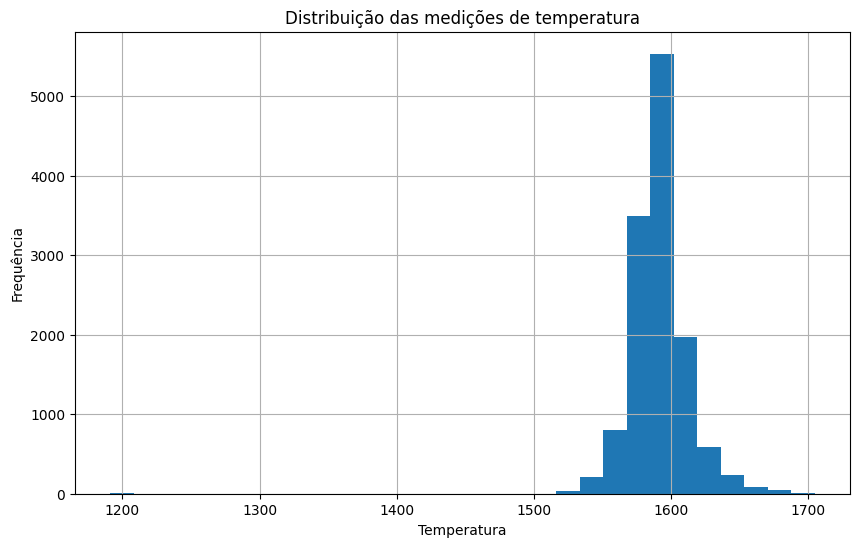

In [15]:
plt.figure(figsize=[10, 6])
data_temp['Temperature'].dropna().hist(bins=30)
plt.title('Distribuição das medições de temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Frequência')
plt.show()

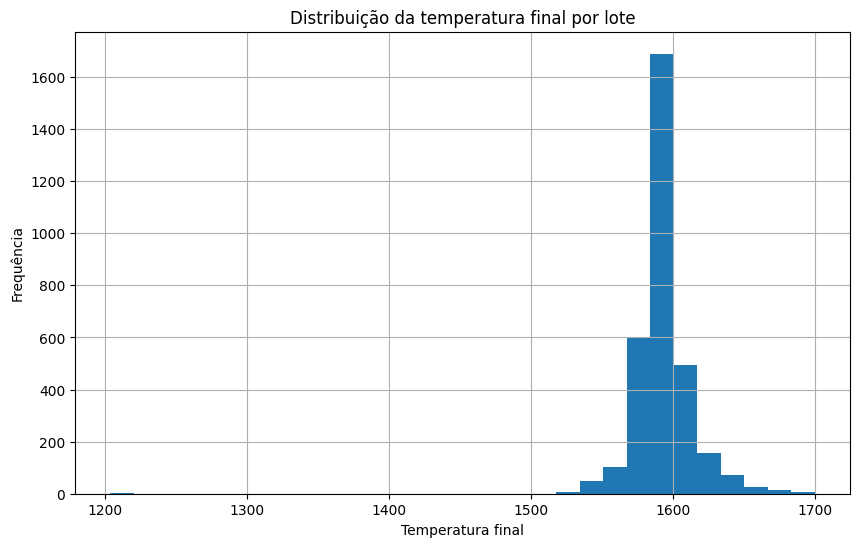

In [16]:
plt.figure(figsize=[10, 6])
last_temp['Temperature'].dropna().hist(bins=30)
plt.title('Distribuição da temperatura final por lote')
plt.xlabel('Temperatura final')
plt.ylabel('Frequência')
plt.show()

In [17]:
data_arc['Arc heating start'] = pd.to_datetime(data_arc['Arc heating start'])
data_arc['Arc heating end'] = pd.to_datetime(data_arc['Arc heating end'])

data_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   key                14876 non-null  int64         
 1   Arc heating start  14876 non-null  datetime64[ns]
 2   Arc heating end    14876 non-null  datetime64[ns]
 3   Active power       14876 non-null  float64       
 4   Reactive power     14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


In [18]:
data_arc['heating_duration_min'] = (
    (data_arc['Arc heating end'] - data_arc['Arc heating start']).dt.total_seconds() / 60
)

data_arc.head()

,key,Arc heating start,Arc heating end,Active power,Reactive power,heating_duration_min
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.98,0.69,3.80
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.81,0.52,3.08
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.74,0.50,2.87
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.66,1.06,6.08
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.69,0.41,2.47


In [19]:
data_arc['heating_duration_min'].describe()

count   14876.00
mean        2.86
std         1.64
min         0.18
25%         1.78
50%         2.45
75%         3.57
max        15.12
Name: heating_duration_min, dtype: float64

In [20]:
arc_agg = data_arc.groupby('key').agg(
    arc_events=('key', 'count'),
    active_power_mean=('Active power', 'mean'),
    active_power_sum=('Active power', 'sum'),
    reactive_power_mean=('Reactive power', 'mean'),
    reactive_power_sum=('Reactive power', 'sum'),
    heating_duration_total_min=('heating_duration_min', 'sum'),
    heating_duration_mean_min=('heating_duration_min', 'mean')
).reset_index()

arc_agg.head()

,key,arc_events,active_power_mean,active_power_sum,reactive_power_mean,reactive_power_sum,heating_duration_total_min,heating_duration_mean_min
0,1,5,0.98,4.88,0.64,3.18,18.30,3.66
1,2,4,0.76,3.05,0.50,2.00,13.52,3.38
2,3,5,0.51,2.53,0.32,1.60,10.92,2.18
3,4,4,0.80,3.21,0.52,2.06,12.35,3.09
4,5,4,0.84,3.35,0.56,2.25,14.48,3.62


### 2.3 Definição da variável-alvo

A análise de `data_temp` indica que a variável-alvo mais adequada para o problema é a **temperatura final do metal por lote**, definida como a última medição de temperatura registrada para cada `key`.

Essa escolha é apropriada por três motivos principais:

1. o problema de negócio está relacionado à necessidade de prever a temperatura do metal ao final do tratamento, etapa crítica para a continuidade do processo produtivo;
2. o dataset de temperatura contém múltiplas medições por lote, o que permite distinguir entre condição inicial e condição final;
3. após ordenar os registros temporalmente, verificou-se que não há valores ausentes na primeira nem na última medição de cada lote, o que torna essa definição do alvo robusta do ponto de vista analítico.

Além disso, a distribuição da temperatura final mostra comportamento concentrado em torno da faixa operacional principal, o que sugere uma variável contínua adequada para modelagem supervisionada de regressão.

### 2.4 Principais atributos preditores

Os dados disponíveis sugerem um conjunto de atributos com forte potencial preditivo para estimar a temperatura final do metal.

Os grupos mais promissores são:

- **Temperatura inicial do lote**, obtida a partir da primeira medição em `data_temp`;
- **Características do aquecimento elétrico** em `data_arc`, como número de eventos, potência ativa média e total, potência reativa e duração total de aquecimento;
- **Adições de materiais a granel** em `data_bulk`, que alteram a composição e podem afetar o balanço térmico do processo;
- **Adições de materiais em arame** em `data_wire`, que também podem influenciar a temperatura;
- **Volume de gás** em `data_gas`, que pode estar relacionado à agitação, purga e comportamento térmico do banho metálico;
- **Informações temporais** de `data_bulk_time` e `data_wire_time`, que poderão ser usadas para derivar sequência de operações, intervalos e duração entre eventos.

Do ponto de vista físico e operacional, faz sentido esperar que a temperatura final seja influenciada tanto pela condição térmica inicial quanto pela intensidade do aquecimento, pelo tempo de processamento e pelas adições realizadas ao longo do tratamento.

In [21]:
temp_features = pd.DataFrame({
    'key': first_temp['key'],
    'temp_initial': first_temp['Temperature'],
    'temp_final': last_temp['Temperature'],
    'time_first_measurement': first_temp['Sampling time'],
    'time_last_measurement': last_temp['Sampling time']
})

temp_features['process_time_min'] = (
    temp_features['time_last_measurement'] - temp_features['time_first_measurement']
).dt.total_seconds() / 60

temp_features.head()

,key,temp_initial,temp_final,time_first_measurement,time_last_measurement,process_time_min
0,1,1571.00,1613.00,2019-05-03 11:16:18,2019-05-03 11:30:39,14.35
1,2,1581.00,1602.00,2019-05-03 11:37:27,2019-05-03 11:59:12,21.75
2,3,1596.00,1599.00,2019-05-03 12:13:17,2019-05-03 12:34:57,21.67
3,4,1601.00,1625.00,2019-05-03 12:52:57,2019-05-03 12:59:25,6.47
4,5,1576.00,1602.00,2019-05-03 13:23:19,2019-05-03 13:36:01,12.70


In [22]:
temp_features[['temp_initial', 'temp_final', 'process_time_min']].describe()

,temp_initial,temp_final,process_time_min
count,3216.00,3216.00,3216.00
mean,1588.59,1593.93,30.66
std,29.14,19.87,20.78
min,1191.00,1204.00,0.00
25%,1572.00,1585.00,19.62
50%,1588.00,1593.00,26.35
75%,1606.00,1600.00,37.25
max,1684.00,1700.00,392.28


In [23]:
temp_features[['temp_initial', 'temp_final', 'process_time_min']].corr()

,temp_initial,temp_final,process_time_min
temp_initial,1.00,0.56,0.13
temp_final,0.56,1.00,0.04
process_time_min,0.13,0.04,1.00


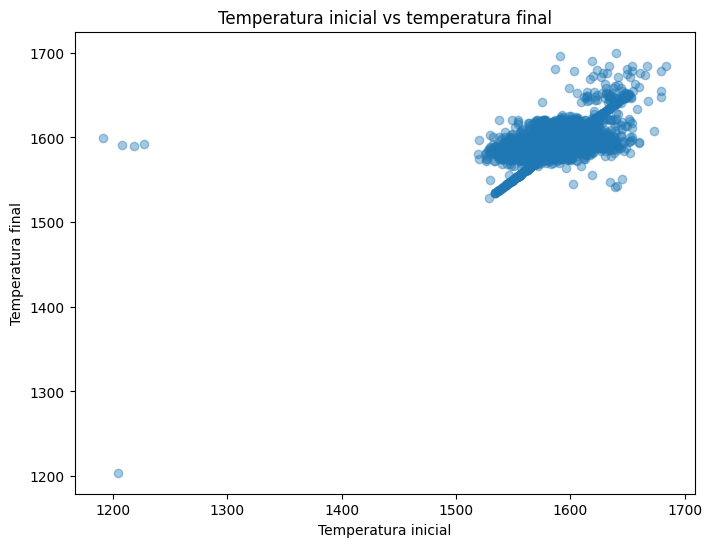

In [24]:
plt.figure(figsize=[8, 6])
plt.scatter(temp_features['temp_initial'], temp_features['temp_final'], alpha=0.4)
plt.title('Temperatura inicial vs temperatura final')
plt.xlabel('Temperatura inicial')
plt.ylabel('Temperatura final')
plt.show()

<div class="alert alert-block alert-success">
<b> Comentário do revisor v1: </b> <a class="tocSkip"></a>

- está correto. Porém, há outliers que dificultam a visualização. Possível solução: plotar outro gráfico apenas com temperatura > 1500

</div>


### 2.5 Conclusão do diagnóstico inicial dos dados

A exploração inicial mostra que os dados são compatíveis com a construção futura de um modelo preditivo para temperatura final do metal por lote. A principal tarefa analítica não será obter a variável-alvo em si, mas consolidar corretamente as diferentes fontes em uma base única por `key`.

Os resultados sugerem que o problema deverá ser tratado como uma tarefa de **regressão supervisionada**, em que cada lote será representado por atributos agregados de aquecimento, tempo de processo, volumes de adição e temperatura inicial, enquanto o alvo será a temperatura final.

Também ficou claro que a preparação dos dados será uma etapa decisiva do projeto, sobretudo pela necessidade de:
- agregar tabelas com múltiplos registros por lote;
- converter colunas temporais;
- tratar ausências que provavelmente representam não ocorrência de adição de materiais;
- avaliar possíveis valores extremos e inconsistências operacionais.

## 3. Hipóteses de modelagem

Como a variável-alvo é contínua, o problema deve ser tratado como **regressão**.

Para este caso, três famílias de algoritmos se destacam como candidatas adequadas:

### 1. Regressão Linear
A regressão linear pode funcionar como modelo base por sua simplicidade, interpretabilidade e baixo custo computacional. Ela será útil como benchmark inicial, especialmente para avaliar quanto da variação da temperatura final pode ser explicada por relações aproximadamente lineares entre temperatura inicial, duração do aquecimento, potência e volumes de materiais.

### 2. Random Forest Regressor
O Random Forest Regressor é apropriado porque consegue capturar relações não lineares e interações entre variáveis sem exigir forte preparação matemática dos atributos. Além disso, tende a ser robusto a outliers moderados e pode lidar bem com conjuntos de variáveis agregadas de natureza heterogênea.

### 3. Gradient Boosting Regressor ou CatBoost Regressor
Modelos baseados em boosting são fortes candidatos para alcançar melhor desempenho preditivo. Eles costumam capturar padrões complexos entre variáveis operacionais, tempos e volumes adicionados. Em particular, o CatBoost pode ser interessante por sua robustez, eficiência e bom desempenho em problemas tabulares.

Esses três algoritmos atendem aos requisitos mínimos esperados:
- pertencem à família correta de aprendizado supervisionado para variável contínua;
- podem ser implementados com os dados disponíveis;
- permitem validação rigorosa por métricas de regressão;
- oferecem um equilíbrio entre interpretabilidade, robustez e potencial de desempenho.

A comparação entre um modelo simples, um modelo de ensemble por bagging e um modelo de boosting permitirá avaliar com maior rigor qual abordagem é mais adequada ao problema de negócio.

In [25]:
candidate_models = {
    'LinearRegression': 'modelo base interpretável',
    'RandomForestRegressor': 'modelo ensemble robusto para relações não lineares',
    'CatBoostRegressor_or_GradientBoostingRegressor': 'modelo de boosting com alto potencial preditivo'
}

candidate_models

{'LinearRegression': 'modelo base interpretável',
 'RandomForestRegressor': 'modelo ensemble robusto para relações não lineares',
 'CatBoostRegressor_or_GradientBoostingRegressor': 'modelo de boosting com alto potencial preditivo'}

## 4. Indicadores-chave de desempenho (KPIs)

Como o objetivo é prever uma variável contínua, os principais indicadores de desempenho serão métricas de regressão.

### MAE — Mean Absolute Error
\[
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

O MAE mede o erro absoluto médio entre o valor real e o previsto. Essa será a métrica principal do projeto, pois é facilmente interpretável em unidades de temperatura e representa diretamente o erro médio operacional do modelo.

### RMSE — Root Mean Squared Error
\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\]

O RMSE penaliza mais fortemente erros maiores, sendo útil para identificar modelos que eventualmente acertam bem na média, mas cometem falhas graves em alguns lotes.

### R² — Coeficiente de determinação
\[
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
\]

O R² mede a proporção da variância da variável-alvo explicada pelo modelo. Embora não seja suficiente sozinho, ele ajuda a avaliar o poder explicativo global da solução.

### Limiares mínimos aceitáveis

Como critério inicial de sucesso para a etapa de modelagem, o projeto buscará atingir pelo menos:

- **MAE < 8**
- **RMSE < 11**
- **R² > 0.60**

Esses limiares são coerentes com a necessidade de obter previsões suficientemente precisas para apoiar decisões operacionais sem exigir perfeição irrealista em um processo industrial naturalmente sujeito a variabilidade.

## 5. Desenho experimental

Para garantir uma comparação técnica rigorosa entre os algoritmos, o projeto seguirá um desenho experimental estruturado.

### Estratégias planejadas

**1. Consolidação por lote (`key`)**  
Todos os datasets serão agregados para produzir uma única linha por lote, evitando vazamento de informação e garantindo compatibilidade com a modelagem supervisionada.

**2. Separação entre treino e teste**  
Os dados serão particionados em conjuntos de treinamento e teste para permitir avaliação final imparcial do desempenho dos modelos.

**3. Validação cruzada**  
Durante o desenvolvimento, será utilizada validação cruzada no conjunto de treinamento para reduzir a dependência de uma única partição e tornar a comparação entre modelos mais robusta.

**4. Ajuste de hiperparâmetros**  
Os modelos de ensemble serão otimizados por meio de busca de hiperparâmetros, com o objetivo de reduzir erro preditivo sem comprometer a capacidade de generalização.

**5. Tratamento de valores ausentes**  
Os ausentes que representarem ausência real de material adicionado poderão ser substituídos por zero, enquanto casos ambíguos serão avaliados separadamente.

**6. Padronização quando necessária**  
Algoritmos sensíveis à escala, como a regressão linear, poderão se beneficiar de padronização dos atributos numéricos. Já modelos baseados em árvores geralmente não exigem esse passo.

**7. Análise de importância das variáveis**  
Modelos baseados em árvores permitirão investigar quais atributos mais contribuem para a previsão da temperatura final, o que aumenta a interpretabilidade prática da solução.

Essas estratégias devem contribuir para atingir os limiares definidos nos KPIs, equilibrando qualidade preditiva, robustez metodológica e aplicabilidade ao contexto de negócio.

## 6. Ações a executar

A seguir está o plano de trabalho para a condução do projeto ao longo de duas semanas.

### 6.1 Processamento e limpeza de dados
1. Verificar integridade estrutural dos datasets e consistência da chave `key` — **0,5 dia**  
2. Converter colunas temporais para formato `datetime` — **0,5 dia**  
3. Avaliar e tratar valores ausentes, distinguindo ausência real de material e possível falha de registro — **1 dia**  
4. Investigar valores extremos e inconsistências operacionais — **0,5 dia**

### 6.2 Preparação de dados
1. Agregar os dados por lote para formar uma base analítica única — **1 dia**  
2. Criar atributos derivados, como temperatura inicial, temperatura final, duração de aquecimento e tempo total de processo — **1 dia**  
3. Tratar variáveis numéricas para modelagem, incluindo preenchimento, seleção e eventual padronização — **0,5 dia**  
4. Separar os dados em treino e teste — **0,5 dia**

### 6.3 Desenvolvimento de modelos
1. Treinar modelo base de regressão linear — **0,5 dia**  
2. Treinar modelo Random Forest Regressor — **0,5 dia**  
3. Treinar modelo de boosting — **0,5 dia**  
4. Ajustar hiperparâmetros dos modelos mais promissores — **1 dia**  
5. Comparar resultados com validação cruzada e conjunto de teste — **0,5 dia**

### 6.4 Comunicação de resultados
1. Construir visualizações e tabelas comparativas de desempenho — **0,5 dia**  
2. Elaborar relatório final com conclusões técnicas e implicações de negócio — **1 dia**

### 6.5 Reserva para revisão e ajustes
1. Revisar notebook, comentários, markdowns e possíveis correções do avaliador — **1 dia**

O cronograma total permanece compatível com a duração estimada de duas semanas para o projeto.

## 7. Stakeholders impactados

Os principais stakeholders interessados nos resultados deste projeto são:

### Operação da aciaria
A equipe operacional é diretamente impactada, pois decisões sobre aquecimento, adição de materiais e momento de encerramento do tratamento dependem do controle da temperatura do metal.

### Engenharia de processo / metalurgia
Essa área se beneficiará do modelo para entender melhor os fatores que influenciam a temperatura final e apoiar a otimização do processo com maior base analítica.

### Gestão industrial
A liderança da planta tem interesse direto na redução de custos energéticos, no aumento da eficiência operacional e na estabilidade do processo produtivo.

### Qualidade
Como a temperatura influencia a conformidade do aço para etapas posteriores, a área de qualidade também será impactada pelos resultados e pela maior previsibilidade do processo.

### Sustentabilidade e eficiência energética
Caso a empresa acompanhe metas de consumo energético ou eficiência operacional, o projeto pode contribuir para iniciativas voltadas à redução de desperdícios e uso mais racional de energia.

## 8. Conclusão da etapa

Nesta etapa foi elaborado um plano de trabalho para orientar o desenvolvimento do modelo preditivo de temperatura final do metal na Steelproof.

A análise inicial permitiu identificar a variável-alvo, os principais grupos de atributos candidatos, os principais riscos de preparação de dados e os algoritmos mais promissores para o problema. Também foram definidos indicadores de desempenho, critérios mínimos de sucesso, desenho experimental e um plano de execução compatível com o prazo do projeto.

Com isso, o projeto fica estruturado para avançar à próxima fase, dedicada à construção efetiva da base analítica e ao desenvolvimento dos modelos de regressão.

## 9. Perguntas de esclarecimento

Antes de avançar para a etapa de modelagem, algumas questões de negócio e de dados deveriam ser esclarecidas com a equipe responsável:

1. **Qual definição operacional de temperatura deve ser prevista?**  
   Confirmar se a variável-alvo esperada é realmente a última temperatura medida em cada lote ou se existe outra medição de referência usada pela operação.

2. **Como interpretar os valores ausentes nos datasets de materiais (`data_bulk` e `data_wire`)?**  
   Validar se valores ausentes significam ausência de adição do material ou falha de registro.

3. **Os valores extremos de temperatura e de potência reativa representam eventos operacionais reais?**  
   Confirmar se esses casos devem ser mantidos, tratados como outliers ou removidos.

4. **Existe alguma restrição de erro aceitável do ponto de vista operacional?**  
   Entender qual margem de erro em graus ainda é útil para apoiar a tomada de decisão na planta.

5. **Há variáveis adicionais não incluídas neste conjunto de dados que influenciam a temperatura final?**  
   Por exemplo, composição química prévia, massa efetiva do lote, tipo de aço ou condições operacionais específicas.

## 10. Plano geral de resolução da tarefa

### Passo 1 — Consolidar e preparar os dados
Os diferentes arquivos serão integrados por `key` para formar uma única base analítica por lote. Nessa etapa, também serão convertidas as variáveis temporais e tratados valores ausentes e possíveis inconsistências.

### Passo 2 — Definir a variável-alvo e construir os atributos
A temperatura final por lote será definida como alvo do modelo, enquanto atributos como temperatura inicial, duração do aquecimento, potência elétrica, uso de gás e adição de materiais serão transformados em variáveis preditoras.

### Passo 3 — Treinar e comparar modelos de regressão
Serão desenvolvidos modelos de regressão com diferentes níveis de complexidade, começando por um modelo base interpretável e avançando para algoritmos de ensemble mais robustos.

### Passo 4 — Validar e otimizar a solução
Os modelos serão avaliados com métricas apropriadas, validação cruzada e ajuste de hiperparâmetros, buscando melhorar a capacidade preditiva e reduzir o erro médio.

### Passo 5 — Interpretar os resultados e comunicar recomendações
Ao final, serão analisados os fatores mais relevantes para a previsão da temperatura e apresentadas conclusões técnicas e de negócio, com foco em eficiência energética e apoio à operação da Steelproof.